# Análisis Comparativo: Método Exacto (Informe 1) vs. PSO (Informe 2)

**Fase 3 de 3.** Contrasta los resultados de PSO (`2_Experimentacion/resultados_pso.csv`) contra el método exacto de Laporte & Nobert (1983) del Informe 1, sobre las 5 instancias que ambos comparten, y caracteriza la escalabilidad de PSO en las 4 instancias adicionales fuera del alcance del exacto.

**Nota de infraestructura:** el método exacto (Informe 1) se ejecutó en Google Colab; PSO (este informe) se ejecutó en el mismo equipo personal usado en el proyecto QAP (Intel Core i9-11900K, 8 núcleos, 3.50 GHz, 32 GB RAM, Windows 11 Home). Por esto, la comparación de tiempo se interpreta en términos de **órdenes de magnitud y tendencia de escalabilidad**, no como una cifra exacta comparable número a número entre ambos métodos.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cvrp_common as cc

EXP_DIR = Path("../2_Experimentacion")
FIG_DIR = Path("Figuras")
FIG_DIR.mkdir(exist_ok=True)

df = pd.read_csv(EXP_DIR / "resultados_pso.csv")
with open(EXP_DIR / "historiales_pso.pkl", "rb") as f:
    histories = pickle.load(f)

df.head()

,instancia,n,m,seed,costo,bks,gap_pct,tiempo_s
0,E-n13-k4,12,4,0,257.0,247.0,4.048583,0.067471
1,E-n13-k4,12,4,1,257.0,247.0,4.048583,0.065821
2,E-n13-k4,12,4,2,251.0,247.0,1.619433,0.067087
3,E-n13-k4,12,4,3,257.0,247.0,4.048583,0.065203
4,E-n13-k4,12,4,4,257.0,247.0,4.048583,0.066205


## Resultados del método exacto (Informe 1)

Datos ya reportados y evaluados (no se reejecutan). `A-n33-k5` no alcanzó certificado de optimalidad: el valor `optimo_certificado=False` marca que 667 es la mejor entera encontrada bajo el límite de 60s por resolución (4.7h de corrida total), no el óptimo demostrado; el óptimo real de esa instancia (661) se usa como referencia de BKS en el resto del análisis.

In [2]:
exacto = pd.DataFrame([
    {"instancia": "E-n13-k4", "z_exacto": 247, "optimo_certificado": True,  "iter_exacto": 15,  "cortes_exacto": 47,   "tiempo_exacto_s": 0.9},
    {"instancia": "E-n22-k4", "z_exacto": 375, "optimo_certificado": True,  "iter_exacto": 13,  "cortes_exacto": 84,   "tiempo_exacto_s": 0.8},
    {"instancia": "E-n23-k3", "z_exacto": 569, "optimo_certificado": True,  "iter_exacto": 16,  "cortes_exacto": 135,  "tiempo_exacto_s": 1.2},
    {"instancia": "A-n32-k5", "z_exacto": 784, "optimo_certificado": True,  "iter_exacto": 99,  "cortes_exacto": 788,  "tiempo_exacto_s": 576.1},
    {"instancia": "A-n33-k5", "z_exacto": 667, "optimo_certificado": False, "iter_exacto": 384, "cortes_exacto": 2846, "tiempo_exacto_s": 17096.4},
]).set_index("instancia")
exacto

,z_exacto,optimo_certificado,iter_exacto,cortes_exacto,tiempo_exacto_s
instancia,,,,,
E-n13-k4,247,True,15,47,0.9
E-n22-k4,375,True,13,84,0.8
E-n23-k3,569,True,16,135,1.2
A-n32-k5,784,True,99,788,576.1
A-n33-k5,667,False,384,2846,17096.4


## Contraste directo (5 instancias compartidas): calidad y tiempo

In [3]:
SHARED = ["E-n13-k4", "E-n22-k4", "E-n23-k3", "A-n32-k5", "A-n33-k5"]
SCALE_ONLY = ["A-n60-k9", "A-n80-k10", "E-n76-k10", "E-n101-k8"]

pso_summary = df.groupby("instancia").agg(
    n=("n", "first"), bks=("bks", "first"),
    costo_mejor=("costo", "min"), costo_prom=("costo", "mean"), costo_std=("costo", "std"),
    gap_mejor=("gap_pct", "min"), gap_prom=("gap_pct", "mean"), gap_std=("gap_pct", "std"),
    tiempo_prom_s=("tiempo_s", "mean"),
)

comparativa = pso_summary.loc[SHARED].join(exacto)
comparativa["gap_exacto_pct"] = cc.gap_pct(comparativa["z_exacto"], comparativa["bks"])
comparativa["razon_tiempo_pso_exacto"] = comparativa["tiempo_prom_s"] / comparativa["tiempo_exacto_s"]
cols = ["n", "bks", "z_exacto", "gap_exacto_pct", "optimo_certificado",
        "costo_mejor", "gap_mejor", "costo_prom", "gap_prom",
        "tiempo_exacto_s", "tiempo_prom_s", "razon_tiempo_pso_exacto"]
comparativa[cols].to_csv("comparativa_exacto_vs_pso.csv")
comparativa[cols]

,n,bks,z_exacto,gap_exacto_pct,optimo_certificado,costo_mejor,gap_mejor,costo_prom,gap_prom,tiempo_exacto_s,tiempo_prom_s,razon_tiempo_pso_exacto
instancia,,,,,,,,,,,,
E-n13-k4,12,247.0,247,0.000000,True,251.0,1.619433,256.612903,3.891864,0.9,0.066206,0.073562
E-n22-k4,21,375.0,375,0.000000,True,376.0,0.266667,392.483871,4.662366,0.8,0.086378,0.107972
E-n23-k3,22,569.0,569,0.000000,True,569.0,0.000000,569.193548,0.034016,1.2,0.095678,0.079732
A-n32-k5,31,784.0,784,0.000000,True,786.0,0.255102,816.709677,4.172153,576.1,0.105542,0.000183
A-n33-k5,32,661.0,667,0.907716,False,697.0,5.446293,727.580645,10.072715,17096.4,0.105960,0.000006


## Escalabilidad (4 instancias fuera del alcance del método exacto)

Estas instancias no fueron resueltas por el método exacto (habrían requerido un tiempo de cómputo excesivo, en línea con lo observado en `A-n33-k5`: 4.7h y aun así sin certificar optimalidad para n=32). Se reporta solo el desempeño de PSO frente al BKS de CVRPLIB.

In [4]:
escalabilidad = pso_summary.loc[SCALE_ONLY][
    ["n", "bks", "costo_mejor", "gap_mejor", "costo_prom", "gap_prom", "gap_std", "tiempo_prom_s"]
]
escalabilidad.to_csv("escalabilidad_pso.csv")
escalabilidad

,n,bks,costo_mejor,gap_mejor,costo_prom,gap_prom,gap_std,tiempo_prom_s
instancia,,,,,,,,
A-n60-k9,59,1354.0,1486.0,9.748892,1560.548387,15.254681,4.161219,0.172370
A-n80-k10,79,1763.0,1911.0,8.394782,2045.354839,16.015589,4.045229,0.225964
E-n76-k10,75,830.0,924.0,11.325301,1013.193548,22.071512,4.852438,0.211996
E-n101-k8,100,815.0,954.0,17.055215,1033.709677,26.835543,5.419573,0.306362


## Distribución del GAP% de PSO por instancia (31 corridas)

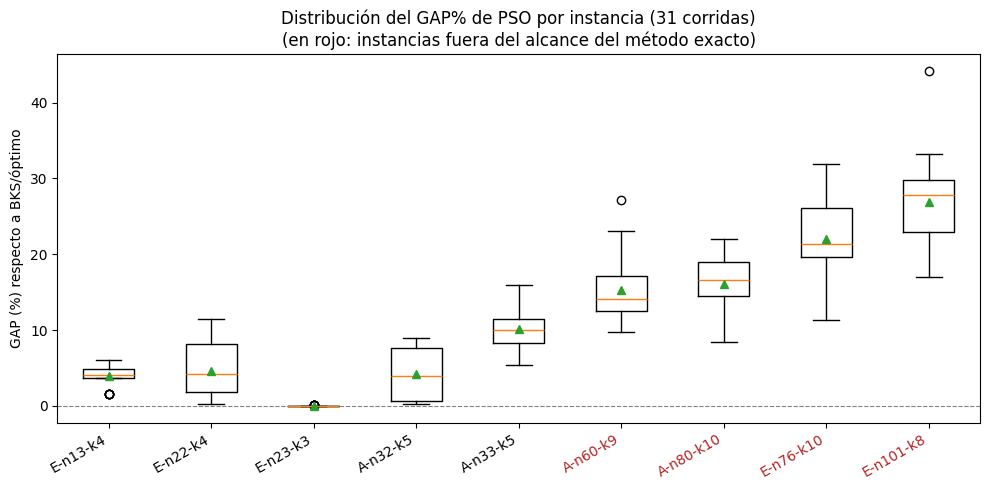

In [5]:
order = SHARED + SCALE_ONLY
data = [df.loc[df["instancia"] == name, "gap_pct"].values for name in order]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(data, labels=order, showmeans=True)
for i, name in enumerate(order):
    if name in SCALE_ONLY:
        ax.get_xticklabels()[i].set_color("firebrick")
ax.set_ylabel("GAP (%) respecto a BKS/óptimo")
ax.set_title("Distribución del GAP% de PSO por instancia (31 corridas)\n(en rojo: instancias fuera del alcance del método exacto)")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "boxplot_gap_pso.png", dpi=150)
plt.show()

## Curvas de convergencia

Línea: corrida mediana (de las 31); banda: rango mejor-peor. Una instancia chica compartida con el exacto (`A-n32-k5`) y una grande de solo-PSO (`E-n101-k8`), para contrastar velocidad de convergencia relativa al tamaño.

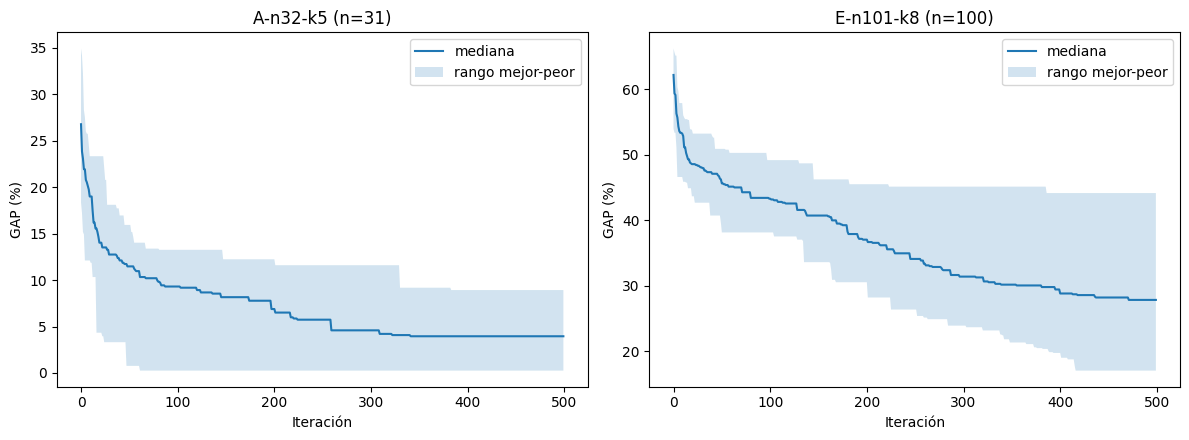

In [6]:
def plot_convergence(ax, name, bks):
    hist_matrix = np.stack([histories[(name, s)] for s in SEEDS if (name, s) in histories])
    gap_matrix = cc.gap_pct(hist_matrix, bks)
    median = np.median(gap_matrix, axis=0)
    best = np.min(gap_matrix, axis=0)
    worst = np.max(gap_matrix, axis=0)
    x = np.arange(len(median))
    ax.plot(x, median, label="mediana")
    ax.fill_between(x, best, worst, alpha=0.2, label="rango mejor-peor")
    ax.set_title(f"{name} (n={instances_n[name]})" if name in instances_n else name)
    ax.set_xlabel("Iteración")
    ax.set_ylabel("GAP (%)")
    ax.legend()

SEEDS = sorted({s for (_, s) in histories.keys()})
instances_n = df.drop_duplicates("instancia").set_index("instancia")["n"].to_dict()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_convergence(axes[0], "A-n32-k5", exacto.loc["A-n32-k5", "z_exacto"])
plot_convergence(axes[1], "E-n101-k8", pso_summary.loc["E-n101-k8", "bks"])
plt.tight_layout()
plt.savefig(FIG_DIR / "convergencia_comparacion.png", dpi=150)
plt.show()

## Convergencia de PSO vs. resultado final del método exacto (tiempo real)

El método exacto no tiene una curva de convergencia comparable a PSO en esta comparación (no se re-ejecutó para registrar el incumbente por iteración); se reporta como un único punto: el tiempo que tardó y el GAP% que alcanzó al terminar (según indicó el ayudante). El eje X es tiempo real en segundos, en escala logarítmica dado el rango de varios órdenes de magnitud entre PSO (~0.1s) y el exacto (hasta 4.7h en `A-n33-k5`). El tiempo de PSO por iteración se aproxima como `tiempo_total / n_iter` (costo por iteración aproximadamente constante, tamaño de enjambre fijo).

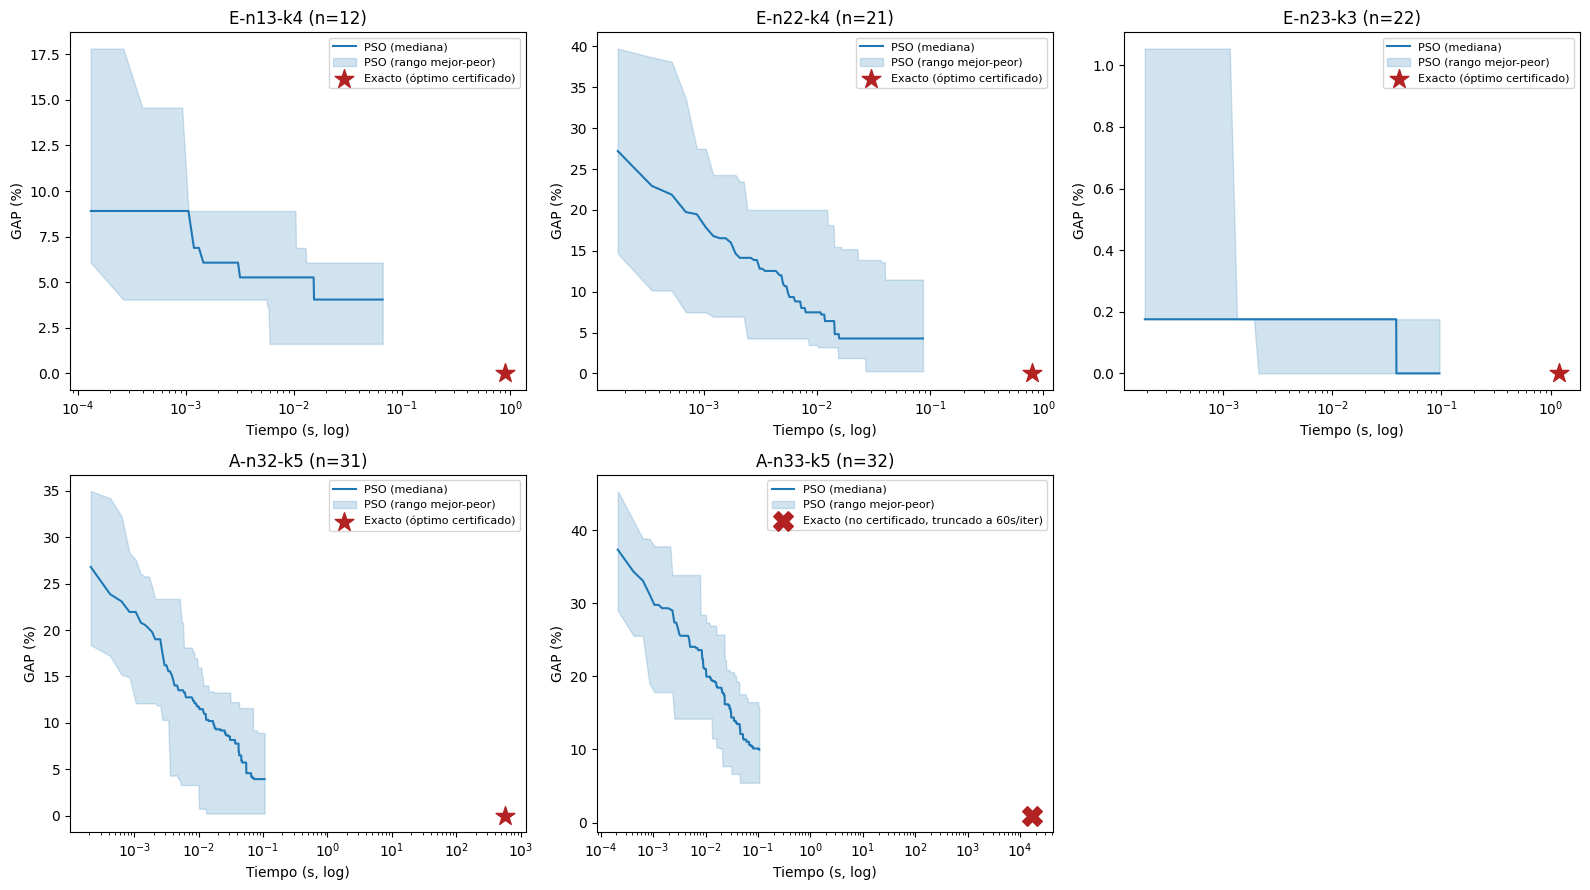

In [7]:
N_ITER = len(next(iter(histories.values())))  # largo de la historia = n_iter usado en la experimentacion

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, name in zip(axes, SHARED):
    bks = pso_summary.loc[name, "bks"]
    hist_matrix = np.stack([histories[(name, s)] for s in SEEDS if (name, s) in histories])
    gap_matrix = cc.gap_pct(hist_matrix, bks)

    tiempo_prom_run = pso_summary.loc[name, "tiempo_prom_s"]
    t_axis = (np.arange(1, N_ITER + 1) / N_ITER) * tiempo_prom_run

    median = np.median(gap_matrix, axis=0)
    best = np.min(gap_matrix, axis=0)
    worst = np.max(gap_matrix, axis=0)

    ax.plot(t_axis, median, label="PSO (mediana)", color="tab:blue")
    ax.fill_between(t_axis, best, worst, alpha=0.2, color="tab:blue", label="PSO (rango mejor-peor)")

    t_exacto = exacto.loc[name, "tiempo_exacto_s"]
    gap_exacto = comparativa.loc[name, "gap_exacto_pct"]
    certificado = exacto.loc[name, "optimo_certificado"]
    marker = "*" if certificado else "X"
    label_exacto = "Exacto (óptimo certificado)" if certificado else "Exacto (no certificado, truncado a 60s/iter)"
    ax.scatter([t_exacto], [gap_exacto], color="firebrick", marker=marker, s=200, zorder=5, label=label_exacto)

    ax.set_xscale("log")
    ax.set_xlabel("Tiempo (s, log)")
    ax.set_ylabel("GAP (%)")
    ax.set_title(f"{name} (n={instances_n[name]})")
    ax.legend(fontsize=8)

axes[-1].axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "convergencia_tiempo_exacto_vs_pso.png", dpi=150)
plt.show()